# My SNOTEL Analysis (Great Salt Lake Basin)
#### NWIS Site: 10109000 (Logan River)
#### Water Year: 2026

## Imports

In [55]:
from pynhd import NLDI
import geopandas as gpd
import pandas as pd
import numpy as np
import datetime
import os
import warnings
import requests

from supporting_scripts import mapping, SNOTEL_Analyzer

warnings.filterwarnings("ignore")

## Settings

In [56]:
usgs_gage_id = "10109000"
WY = 2026
stateab = "UT"   # keep as UT

BASE_OUT = "files"
OutputFolder = os.path.join(BASE_OUT, f"SNOTEL_{stateab}")
os.makedirs(OutputFolder, exist_ok=True)
os.makedirs(BASE_OUT, exist_ok=True)

nldi = NLDI()

## Basin and gage point

In [57]:
basin = nldi.get_basins(usgs_gage_id)
site_feature = nldi.getfeature_byid("nwissite", f"USGS-{usgs_gage_id}")

basin_fp = os.path.join(BASE_OUT, f"{usgs_gage_id}_basin.shp")
basin.to_file(basin_fp)

basin

,geometry
identifier,
USGS-10109000,"POLYGON ((-111.73931 41.72702, -111.75553 41.7..."


## Map Basin

In [58]:
mapping.basin_mapping(basin, site_feature)

## Quick check (should be 3 to 6-ish sites)

In [59]:
gdf_in_bbox = gdf_in_bbox.set_index("code", drop=False)
gdf_in_bbox.index.tolist()

['1115_UT_SNTL', '1013_UT_SNTL', '823_UT_SNTL', '1113_UT_SNTL']

## Map stations

In [60]:
mapping.snotel_mapping(gdf_in_bbox, basin, site_feature)

## Download and clean SWE

In [61]:
def code_to_station_id(code_str: str) -> str:
    # "1115_UT_SNTL" -> "1115"
    return code_str.split("_")[0]

def build_wcc_url(station_id: str, stateab: str, start_date: str, end_date: str) -> str:
    return (
        "https://wcc.sc.egov.usda.gov/reportGenerator/view_csv/"
        "customMultiTimeSeriesGroupByStationReport/daily/start_of_period/"
        f"{station_id}:{stateab}:SNTL%7Cid=%22%22%7Cname/"
        f"{start_date},{end_date}/WTEQ::value?fitToScreen=false"
    )

def download_snotel_csv(site_name, code_str, stateab, start_date, end_date, out_folder):
    station_id = code_to_station_id(code_str)
    url = build_wcc_url(station_id, stateab, start_date, end_date)
    print("downloading:", code_str, site_name)

    r = requests.get(url, timeout=60)
    r.raise_for_status()

    out_fp = os.path.join(out_folder, f"df_{code_str}_{stateab}_SNTL.csv")
    with open(out_fp, "wb") as f:
        f.write(r.content)

    return out_fp

## Download all site CSVs

In [62]:
# make begin/end date strings
gdf_in_bbox["beginDate"] = pd.to_datetime(gdf_in_bbox["beginDate"]).dt.strftime("%Y-%m-%d")
gdf_in_bbox["endDate"]   = pd.to_datetime(gdf_in_bbox["endDate"]).dt.strftime("%Y-%m-%d")

downloaded = []
for i in gdf_in_bbox.index:
    fp = download_snotel_csv(
        gdf_in_bbox.loc[i, "name"],
        gdf_in_bbox.loc[i, "code"],
        stateab,
        gdf_in_bbox.loc[i, "beginDate"],
        gdf_in_bbox.loc[i, "endDate"],
        OutputFolder
    )
    downloaded.append(fp)

len(downloaded), downloaded[:3]

downloading: 1115_UT_SNTL Klondike Narrows
downloading: 1013_UT_SNTL Temple Fork
downloading: 823_UT_SNTL Tony Grove Lake
downloading: 1113_UT_SNTL Tony Grove RS


(4,
 ['files/SNOTEL_UT/df_1115_UT_SNTL_UT_SNTL.csv',
  'files/SNOTEL_UT/df_1013_UT_SNTL_UT_SNTL.csv',
  'files/SNOTEL_UT/df_823_UT_SNTL_UT_SNTL.csv'])

## Clean each CSV and build a standard dataframe

In [63]:
import glob

for fp in glob.glob(os.path.join(OutputFolder, f"df_*_{stateab}_SNTL.csv")):
    df = pd.read_csv(fp, comment="#")

    swe_src = [c for c in df.columns if "Snow Water Equivalent" in c]
    if not swe_src:
        print("No SWE col found in:", fp)
        continue
    swe_src = swe_src[0]

    # analyzer expects inches column name
    df = df.rename(columns={swe_src: "Snow Water Equivalent (in) Start of Day Values"})

    # numeric
    df["Snow Water Equivalent (in) Start of Day Values"] = pd.to_numeric(
        df["Snow Water Equivalent (in) Start of Day Values"], errors="coerce"
    )

    # date + WY + M/D/Y (analyzer uses these)
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    df["Water_Year"] = df["Date"].dt.year + (df["Date"].dt.month >= 10).astype(int)
    df["M"] = df["Date"].dt.month
    df["D"] = df["Date"].dt.day
    df["Y"] = df["Date"].dt.year

    df.to_csv(fp, index=False)

print("cleaned for analyzer")

cleaned for analyzer


## Build sitedict for plotting

In [64]:
sites = gdf_in_bbox["code"].tolist()

sitedict = {}
for code in sites:
    fp = os.path.join(OutputFolder, f"df_{code}_{stateab}_SNTL.csv")
    sitedict[code] = pd.read_csv(fp, parse_dates=["Date"])

print("sites in sitedict:", list(sitedict.keys()))

sites in sitedict: ['1115_UT_SNTL', '1013_UT_SNTL', '823_UT_SNTL', '1113_UT_SNTL']


In [65]:
for k, df in sitedict.items():
    print(k, "WY rows:", (df["Water_Year"] == WY).sum(), "total rows:", len(df))

1115_UT_SNTL WY rows: 155 total rows: 5999
1013_UT_SNTL WY rows: 155 total rows: 8886
823_UT_SNTL WY rows: 155 total rows: 17322
1113_UT_SNTL WY rows: 155 total rows: 5999


In [69]:
import importlib
from supporting_scripts import SNOTEL_Analyzer
importlib.reload(SNOTEL_Analyzer)

<module 'supporting_scripts.SNOTEL_Analyzer' from '/uufs/chpc.utah.edu/common/home/u1257442/Data-Acquisition-Processing-Analysis/supporting_scripts/SNOTEL_Analyzer.py'>

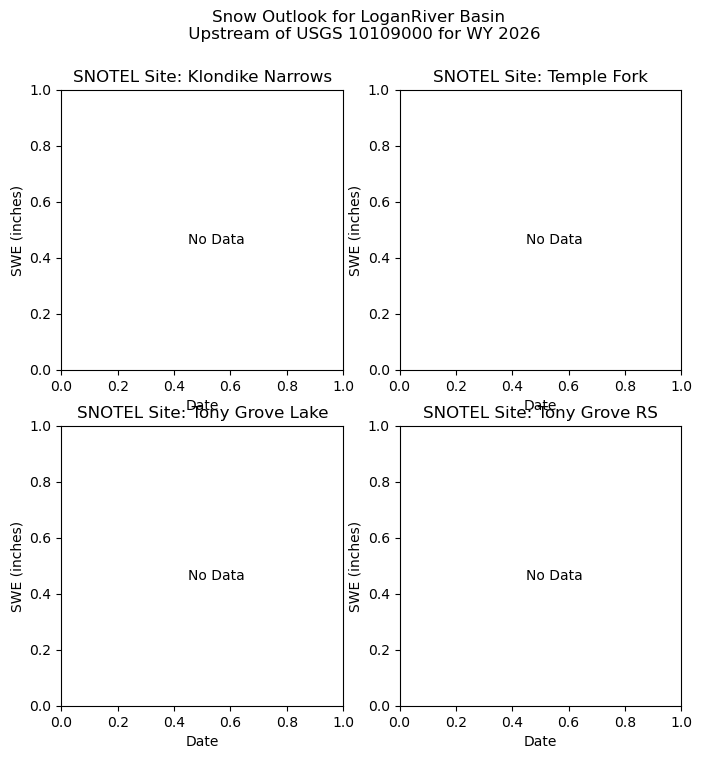

In [70]:
watershed = "LoganRiver"
AOI = f"Upstream of USGS {usgs_gage_id}"
DOI = "03-04"

SNOTEL_Analyzer.SNOTELPlots(sitedict, gdf_in_bbox, WY, watershed, AOI, DOI)